# Chapter 5 — Tools for Data Analytics

**Course 888102 — International College of Digital Innovation, Chiang Mai University**

> *You have already used two of these four tool categories in every notebook so far.*

Chapter 3 argued that big data is defined by the moment ordinary tools stop working. This chapter is about
what you reach for instead — and, more usefully, **how to decide** which one, because the honest answer to
"which is the best big data tool?" is always "for what?"

The chapter has a hidden agenda worth stating up front: almost every tool here is a specific answer to a
specific constraint. Once you see the constraint, the tool stops being a name to memorize and becomes an
obvious consequence.

### Learning objectives

By the end of this chapter you should be able to:

1. **Know the tools** — identify the tools available for data analytics and what category each belongs to.
2. **Select the right one** — choose a suitable tool for a given data analytics task, and justify the choice
   from the shape of the data and the workload.

### How this notebook is organized

| Section | What it covers |
|---|---|
| 1 | Operational vs. analytical workloads — and why the split drives everything else |
| 2 | The landscape: four categories, four questions |
| 3 | Storage: RDBMS, NoSQL, cloud storage, Hadoop HDFS |
| 4 | Mining, analytics, and visualization tools |
| 5 | Emerging technologies: TensorFlow, Docker, Beam, Airflow |
| 6 | Choosing the right tool |
| 7–9 | Glossary, self-check quiz, summary |
| 10 | Graded homework 📝 |

In [1]:
# Run this cell first — everything below depends on it.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import time
import json

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

rng = np.random.default_rng(888102)   # fixed seed: identical numbers for every student

print("Ready. pandas", pd.__version__, "| networkx", nx.__version__)

Ready. pandas 3.0.5 | networkx 3.6.1


---
## 1. Operational vs. analytical

A **big data technology** is a software utility designed to analyze, process, and extract information from
data sets that traditional data processing software could never handle. They split into two types, and this
is the first fork in the road for every decision in the chapter:

| | **Operational** | **Analytical** |
|---|---|---|
| **What it does** | Real-time, interactive workloads where data is primarily captured and stored | Retrospective, complex analysis that may touch most or all of the data |
| **Examples** | Online ticket booking, social media, online shopping | Stock market modeling, weather forecasting, medical research |
| **Touches** | One record at a time | Millions of records at once |
| **Cares about** | Latency (milliseconds) and correctness of each write | Throughput; a query taking a minute is fine |
| **Reads vs. writes** | Many small writes and point reads | Almost all reads, and huge ones |
| **Also called** | OLTP — online transaction processing | OLAP — online analytical processing |

In [2]:
scenarios = pd.DataFrame({
    "Scenario": [
        "A customer books a flight ticket online",
        "A hospital analyzes 5 years of patient records for disease patterns",
        "A social media app saves a new post the instant you hit submit",
        "A bank builds a financial model from years of transaction history",
        "A card payment is authorized at a terminal",
        "The marketing team segments 2 million customers by behavior",
    ],
    "Type": ["Operational", "Analytical", "Operational",
             "Analytical", "Operational", "Analytical"],
    "Why": [
        "one record, must succeed now",
        "whole history, no deadline",
        "one record, must succeed now",
        "whole history, no deadline",
        "one record, deadline in milliseconds",
        "whole population, runs overnight",
    ],
})
scenarios

,Scenario,Type,Why
0,A customer books a flight ticket online,Operational,"one record, must succeed now"
1,A hospital analyzes 5 years of patient records...,Analytical,"whole history, no deadline"
2,A social media app saves a new post the instan...,Operational,"one record, must succeed now"
3,A bank builds a financial model from years of ...,Analytical,"whole history, no deadline"
4,A card payment is authorized at a terminal,Operational,"one record, deadline in milliseconds"
5,The marketing team segments 2 million customer...,Analytical,"whole population, runs overnight"


**How to read it:** the giveaway is **time orientation and scope**. If the system must react *right now* to
*one* event, it is operational. If it looks *backward* across a large history to find patterns, it is
analytical.

That distinction is not academic — it changes the physical layout of the data, which is the point of the next
demonstration.

### 1.1 Why the split changes how data is stored on disk

An operational system fetches whole records: *"give me everything about booking 88214."* An analytical system
fetches whole columns: *"give me the average price across 40 million bookings."*

Those two access patterns want opposite physical layouts. **Row storage** keeps each record's fields adjacent;
**column storage** keeps each field's values adjacent across all records.

In [3]:
n_records = 200_000

# ROW-ORIENTED: each record is one object holding all its fields together.
row_store = [{"booking_id": i, "price": float(i % 997), "seat": "A", "meal": "veg", "note": "x" * 20}
             for i in range(n_records)]

# COLUMN-ORIENTED: each field is one contiguous array across all records.
column_store = {
    "booking_id": np.arange(n_records),
    "price": (np.arange(n_records) % 997).astype(float),
    "seat": np.array(["A"] * n_records),
    "meal": np.array(["veg"] * n_records),
}

# Operational query: fetch ONE whole record.
target = 123_456
start = time.perf_counter()
_ = row_store[target]
row_point_read = time.perf_counter() - start

start = time.perf_counter()
_ = {key: values[target] for key, values in column_store.items()}
column_point_read = time.perf_counter() - start

# Analytical query: sum ONE column across ALL records.
start = time.perf_counter()
_ = sum(record["price"] for record in row_store)
row_scan = time.perf_counter() - start

start = time.perf_counter()
_ = column_store["price"].sum()
column_scan = time.perf_counter() - start

comparison = pd.DataFrame({
    "Row storage (s)": [row_point_read, row_scan],
    "Column storage (s)": [column_point_read, column_scan],
}, index=["Fetch one whole record (operational)", "Sum one column, all records (analytical)"])
comparison.round(6)

,Row storage (s),Column storage (s)
Fetch one whole record (operational),0.000021,0.000046
"Sum one column, all records (analytical)",0.005772,0.000108


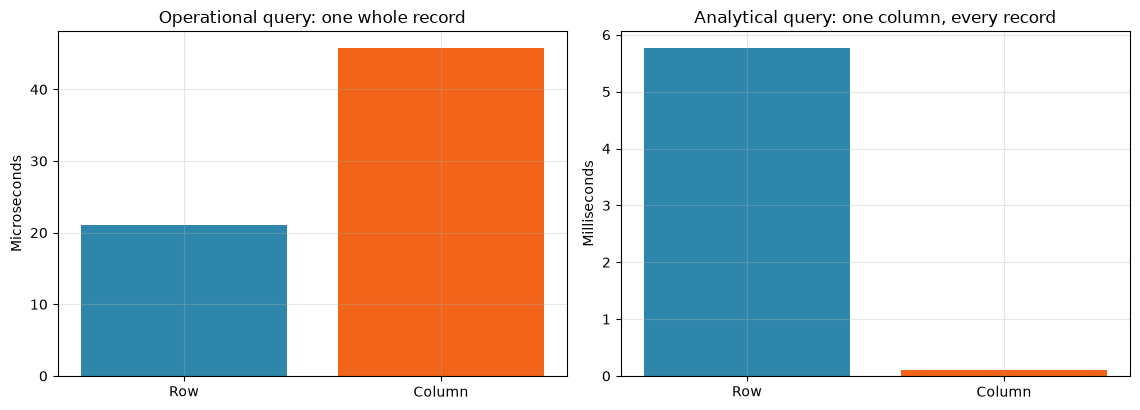

Column storage is about 53x faster on the analytical query.
Merely extracting that column out of row storage takes 7.7 ms —
about 72x the cost of the whole columnar sum.


In [4]:
fig, (ax_point, ax_scan) = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax_point.bar(["Row", "Column"], [row_point_read * 1e6, column_point_read * 1e6],
             color=["#2E86AB", "#F26419"])
ax_point.set_ylabel("Microseconds")
ax_point.set_title("Operational query: one whole record")

ax_scan.bar(["Row", "Column"], [row_scan * 1000, column_scan * 1000],
            color=["#2E86AB", "#F26419"])
ax_scan.set_ylabel("Milliseconds")
ax_scan.set_title("Analytical query: one column, every record")

plt.show()

print(f"Column storage is about {row_scan / column_scan:,.0f}x faster on the analytical query.")

# Being fair: part of that gap is the layout, and part is that the row store forces a
# Python-level loop. Even just EXTRACTING the column out of row storage costs this much:
start = time.perf_counter()
extracted = np.fromiter((record["price"] for record in row_store), dtype=float, count=n_records)
extract_time = time.perf_counter() - start
print(f"Merely extracting that column out of row storage takes {extract_time*1000:,.1f} ms —")
print(f"about {extract_time / column_scan:,.0f}x the cost of the whole columnar sum.")

**How to read it:** the two panels disagree about which layout wins, and that is exactly the point. Fetching
one record is cheap in both. Scanning one column across everything is dramatically faster column-wise, because
the values sit next to each other in memory and the other four fields are never touched at all.

Be careful about what the ratio proves. Part of the gap is the layout itself, and part is that row storage
leaves you no choice but a Python-level loop over objects — which is why the cell also times the *extraction*
step alone. Both effects are real consequences of the same decision: with the values scattered across objects,
there is no contiguous block of numbers for the machine to add quickly, so you pay to gather them before you
can compute anything.

This is why analytical systems (data warehouses, Parquet files, column-based NoSQL stores) are almost all
column-oriented, while operational databases are row-oriented. **The workload dictates the layout**, and the
"which database?" question is largely this question in disguise.

### 1.2 ACID and BASE — two different promises

Operational and analytical systems also make different guarantees, and the vocabulary shows up constantly.

**ACID** is what a traditional relational database promises for each transaction:

| Letter | Guarantee |
|---|---|
| **A**tomicity | A transaction happens completely or not at all — no half-transferred money |
| **C**onsistency | The database moves from one valid state to another; rules are never violated |
| **I**solation | Concurrent transactions do not see each other's partial work |
| **D**urability | Once committed, it survives a power failure |

**BASE** is the trade many distributed NoSQL systems make instead:

| Term | Meaning |
|---|---|
| **B**asically **A**vailable | The system answers, even when parts of it are broken |
| **S**oft state | The state may be in flux without new input |
| **E**ventually consistent | Given time and no new writes, all replicas converge |

Neither is "better." A bank ledger needs ACID; a social-media like counter is perfectly happy being eventually
consistent, and would rather stay available than be exactly right for three seconds.

### 1.3 The CAP theorem — you may pick two

The CAP theorem is the reason BASE exists. For a distributed data store, three properties are desirable:

- **C**onsistency — every read sees the most recent write.
- **A**vailability — every request receives a response.
- **P**artition tolerance — the system keeps working when the network between machines breaks.

**In a distributed system a network partition will eventually happen**, so P is not optional. The real choice
is what to do *during* a partition: refuse to answer and stay consistent (CP), or answer with possibly stale
data and stay available (AP).

In [5]:
cap = pd.DataFrame([
    ("CA", "Consistent + Available",  "Single-machine RDBMS (PostgreSQL, MySQL on one node)",
     "Not really distributed — a partition would take it down"),
    ("CP", "Consistent + Partition-tolerant", "HBase, MongoDB (default), Redis Cluster, ZooKeeper",
     "During a partition, refuses writes rather than diverge"),
    ("AP", "Available + Partition-tolerant", "Cassandra, DynamoDB, CouchDB, DNS",
     "During a partition, keeps answering; replicas reconcile later"),
], columns=["Choice", "Keeps", "Typical systems", "Behavior during a network partition"])

cap

,Choice,Keeps,Typical systems,Behavior during a network partition
0,CA,Consistent + Available,"Single-machine RDBMS (PostgreSQL, MySQL on one...",Not really distributed — a partition would tak...
1,CP,Consistent + Partition-tolerant,"HBase, MongoDB (default), Redis Cluster, ZooKe...","During a partition, refuses writes rather than..."
2,AP,Available + Partition-tolerant,"Cassandra, DynamoDB, CouchDB, DNS","During a partition, keeps answering; replicas ..."


**How to read it:** the row you want depends on what a wrong answer costs.

- A **seat reservation** must not be sold twice, so refusing to answer during a partition (CP) is correct.
- A **product catalog** showing a price three seconds out of date harms nobody, and going offline would cost
  real sales — so AP is correct.

⚠️ CAP is frequently over-simplified into "pick two of three." The precise statement is narrower: **during a
network partition**, you must choose between consistency and availability. When the network is healthy, a
well-built system can offer both.

---
## 2. The landscape — four categories, four questions

Every tool in this chapter falls into one of four categories:

| Category | Question it answers | Examples |
|---|---|---|
| **Data storage** | Where do we keep it? | RDBMS, NoSQL, cloud storage, Hadoop HDFS |
| **Data mining** | What patterns are hiding in it? | RapidMiner, Elasticsearch |
| **Data analytics** | What insights can we compute? | Apache Spark, R |
| **Data visualization** | How do we show it to people? | Tableau, Plotly/Dash |

**You already use two of these.** `pandas` is a data analytics tool and `matplotlib`/`seaborn` are data
visualization tools, and you have run both in every notebook of this course. The categories are not abstract
— this course has been doing them the whole time.

In [6]:
landscape = pd.DataFrame([
    ("Data storage",       "Where do we keep it?",             "RDBMS, NoSQL, cloud storage, HDFS",
     "—", "Chapter 6 reads from these"),
    ("Data mining",        "What patterns are hiding in it?",  "RapidMiner, Elasticsearch",
     "—", "Chapter 4's nine tasks"),
    ("Data analytics",     "What insights can we compute?",    "Apache Spark, R",
     "pandas / numpy", "Every notebook so far"),
    ("Data visualization", "How do we show it to people?",     "Tableau, Plotly/Dash",
     "matplotlib / seaborn", "Chapter 7"),
], columns=["Category", "Question it answers", "Industry examples",
            "What you use in this course", "Where it appears"])

landscape

,Category,Question it answers,Industry examples,What you use in this course,Where it appears
0,Data storage,Where do we keep it?,"RDBMS, NoSQL, cloud storage, HDFS",—,Chapter 6 reads from these
1,Data mining,What patterns are hiding in it?,"RapidMiner, Elasticsearch",—,Chapter 4's nine tasks
2,Data analytics,What insights can we compute?,"Apache Spark, R",pandas / numpy,Every notebook so far
3,Data visualization,How do we show it to people?,"Tableau, Plotly/Dash",matplotlib / seaborn,Chapter 7


---
## 3. Data storage

### 3.1 RDBMS — relational database management systems

An RDBMS stores data in structured tables (rows and columns) and supports reading, creating, updating, and
deleting via **SQL**. Tables are *related* through shared key columns — exactly what pandas' `.merge()` does.

Examples: Oracle, MySQL, Microsoft SQL Server, PostgreSQL, DB2.

In [7]:
# The lecture's relational schema: Department <-> Person, connected by a shared key.
departments = pd.DataFrame({
    "department_id": [1, 2, 3],
    "department_name": ["Engineering", "Marketing", "Finance"],
})
people = pd.DataFrame({
    "person_id": [101, 102, 103, 104],
    "name": ["Nam", "Bo", "Ploy", "Aom"],
    "department_id": [1, 1, 2, 3],   # the FOREIGN KEY linking each person to a department
})

joined = people.merge(departments, on="department_id")
joined

,person_id,name,department_id,department_name
0,101,Nam,1,Engineering
1,102,Bo,1,Engineering
2,103,Ploy,2,Marketing
3,104,Aom,3,Finance


**How to read it:** `department_id` is the shared key that makes the two tables *relational*. Neither table
alone tells you "Nam works in Engineering" — joining them does. This is the exact mechanism an RDBMS uses,
just expressed as SQL (`JOIN ... ON`) instead of `.merge()`.

Two vocabulary items worth fixing now:

- A **primary key** uniquely identifies a row in its own table (`department_id` in `departments`).
- A **foreign key** is a column pointing at another table's primary key (`department_id` in `people`).

#### Why split it into two tables at all? Normalization.

It would be simpler to store `department_name` directly in the `people` table. Normalization says not to, and
the reason is that duplicated data drifts out of agreement.

In [8]:
# The DENORMALIZED version: department name repeated on every person.
denormalized = pd.DataFrame({
    "person_id": [101, 102, 103, 104],
    "name": ["Nam", "Bo", "Ploy", "Aom"],
    "department_name": ["Engineering", "Engineering", "Marketing", "Finance"],
})
print("Denormalized — the department name is stored 4 times:")
print(denormalized.to_string(index=False))

# Marketing is renamed. In the denormalized table, one row is missed.
denormalized.loc[2, "department_name"] = "Growth Marketing"
print("\nAfter renaming Marketing -> Growth Marketing in ONE place:")
print(denormalized.to_string(index=False))

print("\nIn the normalized design, the same rename touches exactly one row:")
departments_renamed = departments.copy()
departments_renamed.loc[departments_renamed["department_id"] == 2, "department_name"] = "Growth Marketing"
print(people.merge(departments_renamed, on="department_id").to_string(index=False))

Denormalized — the department name is stored 4 times:
 person_id name department_name
       101  Nam     Engineering
       102   Bo     Engineering
       103 Ploy       Marketing
       104  Aom         Finance

After renaming Marketing -> Growth Marketing in ONE place:
 person_id name  department_name
       101  Nam      Engineering
       102   Bo      Engineering
       103 Ploy Growth Marketing
       104  Aom          Finance

In the normalized design, the same rename touches exactly one row:
 person_id name  department_id  department_name
       101  Nam              1      Engineering
       102   Bo              1      Engineering
       103 Ploy              2 Growth Marketing
       104  Aom              3          Finance


**How to read it:** with the name duplicated across rows, every rename is an opportunity to update some rows
and miss others — an **update anomaly**. Storing each fact exactly once makes that impossible by construction.

The trade-off is real: normalized designs need joins, and joins cost time. **Operational systems normalize**
(correctness of writes matters most); **analytical systems often deliberately denormalize** (read speed
matters most, and the data is not being updated anyway). Same data, opposite designs, both correct — because
the workloads differ.

In [9]:
# Join types matter more than beginners expect, and the difference is silent data loss.
people_with_orphan = pd.concat([people, pd.DataFrame({
    "person_id": [105], "name": ["Kan"], "department_id": [9],   # department 9 does not exist
})], ignore_index=True)

inner = people_with_orphan.merge(departments, on="department_id", how="inner")
left = people_with_orphan.merge(departments, on="department_id", how="left")
outer = people_with_orphan.merge(departments, on="department_id", how="outer")

print(f"People table has {len(people_with_orphan)} rows (Kan's department 9 does not exist).\n")
print(f"INNER join -> {len(inner)} rows.  Kan silently VANISHES.")
print(f"LEFT  join -> {len(left)} rows.  Kan is kept, with department_name = NaN.")
print(f"OUTER join -> {len(outer)} rows.  Kan kept, AND the unused department appears too.\n")
print(left.to_string(index=False))

People table has 5 rows (Kan's department 9 does not exist).

INNER join -> 4 rows.  Kan silently VANISHES.
LEFT  join -> 5 rows.  Kan is kept, with department_name = NaN.
OUTER join -> 5 rows.  Kan kept, AND the unused department appears too.

 person_id name  department_id department_name
       101  Nam              1     Engineering
       102   Bo              1     Engineering
       103 Ploy              2       Marketing
       104  Aom              3         Finance
       105  Kan              9             NaN


**How to read it:** the inner join quietly dropped a person. No warning, no error — the row count just went
down by one, and if you were computing a headcount you would now be wrong.

**Always check row counts before and after a join.** An unexpected drop means orphaned foreign keys; an
unexpected *increase* means the key is not unique on one side and rows were multiplied. Both are among the
most common bugs in data work, and both are invisible unless you look.

In [10]:
# SQL and pandas say the same things in different words.
translation = pd.DataFrame([
    ("SELECT * FROM people",                              "people"),
    ("SELECT name, department_id FROM people",            "people[['name', 'department_id']]"),
    ("WHERE department_id = 1",                           "people[people.department_id == 1]"),
    ("ORDER BY name",                                     "people.sort_values('name')"),
    ("LIMIT 5",                                           "people.head(5)"),
    ("JOIN departments ON ...",                           "people.merge(departments, on='department_id')"),
    ("GROUP BY department_id",                            "people.groupby('department_id')"),
    ("COUNT(*) ... GROUP BY department_id",               "people.groupby('department_id').size()"),
    ("SELECT DISTINCT department_id",                     "people['department_id'].unique()"),
], columns=["SQL", "pandas"])

translation

,SQL,pandas
0,SELECT * FROM people,people
1,"SELECT name, department_id FROM people","people[['name', 'department_id']]"
2,WHERE department_id = 1,people[people.department_id == 1]
3,ORDER BY name,people.sort_values('name')
4,LIMIT 5,people.head(5)
5,JOIN departments ON ...,"people.merge(departments, on='department_id')"
6,GROUP BY department_id,people.groupby('department_id')
7,COUNT(*) ... GROUP BY department_id,people.groupby('department_id').size()
8,SELECT DISTINCT department_id,people['department_id'].unique()


In [11]:
# The same query, both ways, on the same data.
print("SQL:    SELECT department_name, COUNT(*) FROM people JOIN departments")
print("        USING (department_id) GROUP BY department_name;\n")
print("pandas:")
result = (people.merge(departments, on="department_id")
          .groupby("department_name")
          .size()
          .rename("headcount")
          .reset_index())
print(result.to_string(index=False))

SQL:    SELECT department_name, COUNT(*) FROM people JOIN departments
        USING (department_id) GROUP BY department_name;

pandas:
department_name  headcount
    Engineering          2
        Finance          1
      Marketing          1


> ✏️ **Try it:** add a fourth department (`4, "Operations"`) that nobody works in, then run an inner join and
> a right join. Which one shows the empty department, and when would you want that?

### 3.2 NoSQL — four models, four data shapes

NoSQL databases skip relational rules and fixed schemas. Each of the four models fits a different **shape** of
data, and picking the model is really picking the shape.

In [12]:
# 1. KEY-VALUE — every value looked up by one unique key, like a Python dict.
key_value_store = {
    2398239: {"name": "Michal", "age": 31},
    2398240: "Lorem ipsum dolor sit amet",
}
print("KEY-VALUE:", key_value_store)

# 2. DOCUMENT — each record is a flexible, self-describing document, like JSON.
document_store = [
    {"id": 1, "first": "Frank", "last": "Weigel", "zip": 94040},
    {"id": 2, "first": "Ali", "last": "Bob"},          # no "zip" field, and that is fine
]
print("\nDOCUMENT:", document_store)

# 3. COLUMN-BASED — organized by column instead of by row.
column_store = {
    "name": ["Preston", "Julia", "Alice"],
    "website": ["www.example.com", "www.example.com", "example@example.com"],
}
print("\nCOLUMN-BASED:", column_store)

# 4. GRAPH-BASED — entities and relationships stored as nodes and edges.
graph_store = nx.Graph()
graph_store.add_edge("Alice", "Bob", label="knows", since="2001")
graph_store.add_edge("Bob", "Cheese_group", label="member")
print("\nGRAPH-BASED edges:", list(graph_store.edges(data=True)))

KEY-VALUE: {2398239: {'name': 'Michal', 'age': 31}, 2398240: 'Lorem ipsum dolor sit amet'}

DOCUMENT: [{'id': 1, 'first': 'Frank', 'last': 'Weigel', 'zip': 94040}, {'id': 2, 'first': 'Ali', 'last': 'Bob'}]

COLUMN-BASED: {'name': ['Preston', 'Julia', 'Alice'], 'website': ['www.example.com', 'www.example.com', 'example@example.com']}

GRAPH-BASED edges: [('Alice', 'Bob', {'label': 'knows', 'since': '2001'}), ('Bob', 'Cheese_group', {'label': 'member'})]


**How to read it:** the *document* example shows the key advantage over RDBMS — record #2 has no `zip` field
at all, and that is perfectly valid. No error, no empty column required. An RDBMS table needs every row to
have every column, even if some are `NULL`.

| Model | Shape it fits | Strength | Weakness | Examples |
|---|---|---|---|---|
| **Key-value** | Anything, addressed by one key | Fastest possible lookup; trivially scalable | Cannot query by value; no relationships | Redis, DynamoDB, Memcached |
| **Document** | Self-contained records with varying fields | Flexible schema; whole record in one read | Cross-document joins are awkward | MongoDB, CouchDB, Firestore |
| **Column-based** | Wide tables, analytical scans | Reads one column across billions of rows fast | Poor for fetching whole records | Cassandra, HBase, BigTable |
| **Graph** | Entities and relationships | Traverses connections in constant time per hop | Poor for aggregate scans | Neo4j, Neptune, ArangoDB |

'Who is within 3 hops of Nam?' — one traversal in a graph store:
  1 hop(s): ['Bo', 'Ploy']
  2 hop(s): ['Aom', 'Kan']
  3 hop(s): ['Fah']

In SQL, each extra hop is another self-join:
  1 hop  : friends
  2 hops : friends JOIN friends
  3 hops : friends JOIN friends JOIN friends
  6 hops : six joins — the query plan explodes, which is why graph stores exist.


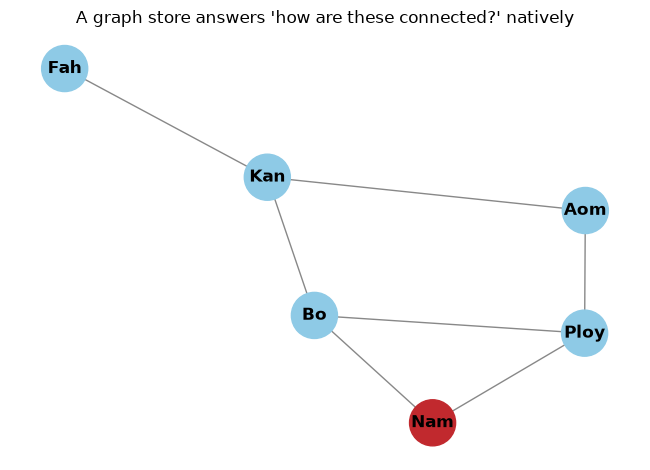

In [13]:
# When does a graph store actually beat a relational one? When you follow connections repeatedly.
social = nx.Graph()
edges = [("Nam", "Bo"), ("Bo", "Ploy"), ("Ploy", "Aom"), ("Aom", "Kan"),
         ("Nam", "Ploy"), ("Kan", "Fah"), ("Bo", "Kan")]
social.add_edges_from(edges)

print("'Who is within 3 hops of Nam?' — one traversal in a graph store:")
for distance in (1, 2, 3):
    reachable = {node for node, d in nx.single_source_shortest_path_length(social, "Nam").items()
                 if d == distance}
    print(f"  {distance} hop(s): {sorted(reachable)}")

print("\nIn SQL, each extra hop is another self-join:")
print("  1 hop  : friends")
print("  2 hops : friends JOIN friends")
print("  3 hops : friends JOIN friends JOIN friends")
print("  6 hops : six joins — the query plan explodes, which is why graph stores exist.")

fig, ax = plt.subplots(figsize=(6.6, 4.8))
pos = nx.spring_layout(social, seed=888102)
colors = ["#C1292E" if node == "Nam" else "#8ECAE6" for node in social.nodes()]
nx.draw(social, pos, ax=ax, with_labels=True, node_color=colors, node_size=1100,
        font_weight="bold", edge_color="#888")
ax.set_title("A graph store answers 'how are these connected?' natively")
ax.grid(False)
plt.show()

**How to read it:** each additional hop costs a graph database one more step and costs a relational database
one more self-join. At two hops SQL is fine; at six it is unusable. That single asymptotic difference is the
entire argument for graph databases, and it is why they show up in fraud rings, supply chains, and social
recommendations — problems that are *about* connections rather than about records.

### 3.3 Cloud storage

Cloud storage means stashing data on hardware in a remote location, accessible from any device via the
internet, instead of on your own hard drives. A handful of providers dominate the market.

**Why it matters:** cloud storage removes the ceiling a single organization's own hardware would otherwise
impose — capacity scales with a subscription, not with a purchase order for new machines.

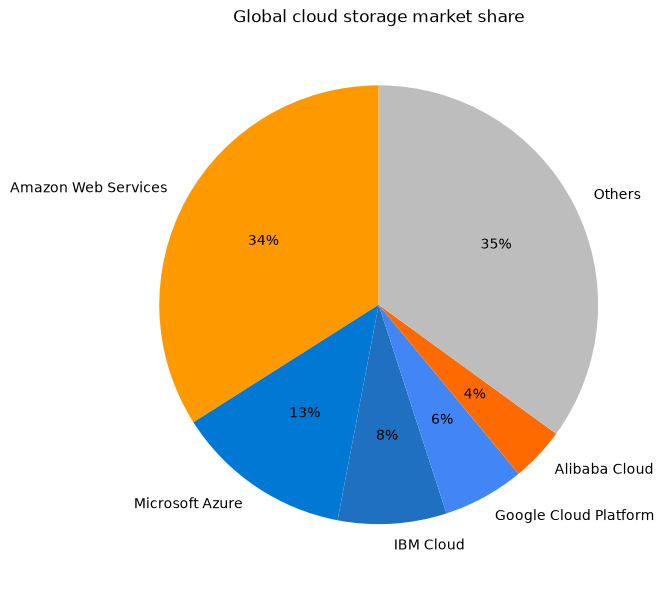

In [14]:
cloud_market_share = pd.Series({
    "Amazon Web Services": 34,
    "Microsoft Azure": 13,
    "IBM Cloud": 8,
    "Google Cloud Platform": 6,
    "Alibaba Cloud": 4,
})
cloud_market_share["Others"] = 100 - cloud_market_share.sum()

fig, ax = plt.subplots(figsize=(6.6, 6))
ax.pie(cloud_market_share, labels=cloud_market_share.index, autopct="%1.0f%%",
       colors=["#FF9900", "#0078D4", "#1F70C1", "#4285F4", "#FF6A00", "#BDBDBD"],
       startangle=90)
ax.set_title("Global cloud storage market share")
plt.show()

**How to read it:** AWS holds roughly a third of the market, with Azure second. The concentration itself is
worth noticing — it is a **vendor lock-in** risk. Moving petabytes between providers is slow and expensive,
and providers price *egress* (data leaving) far higher than storage, which is not a coincidence.

In [15]:
# Cloud storage is priced in tiers. Choosing the wrong one is a common and expensive mistake.
tiers = pd.DataFrame([
    ("Hot / Standard",    0.023, 0.0004, "milliseconds",     "Active data, queried daily"),
    ("Cool / Infrequent", 0.010, 0.0100, "milliseconds",     "Accessed a few times a year"),
    ("Archive / Glacier", 0.001, 0.0500, "minutes to hours", "Compliance, backups, rarely read"),
], columns=["Tier", "USD per GB-month", "USD per GB retrieved", "Retrieval time", "Intended for"])

data_gb = 500 * 1000                       # 500 TB
tiers["Storage / month (500 TB)"] = tiers["USD per GB-month"] * data_gb
tiers

,Tier,USD per GB-month,USD per GB retrieved,Retrieval time,Intended for,Storage / month (500 TB)
0,Hot / Standard,0.023,0.0004,milliseconds,"Active data, queried daily",11500.0
1,Cool / Infrequent,0.010,0.0100,milliseconds,Accessed a few times a year,5000.0
2,Archive / Glacier,0.001,0.0500,minutes to hours,"Compliance, backups, rarely read",500.0


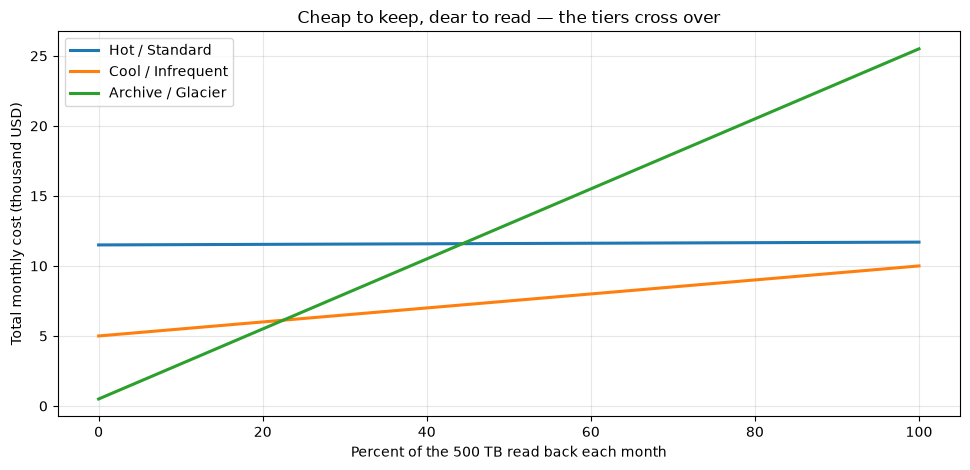

Cheapest tier, as the monthly read fraction rises:
  from  0.0% of the data read back : Archive / Glacier
  from 22.6% of the data read back : Cool / Infrequent

Reading    1% per month -> cheapest is Archive / Glacier
    Hot / Standard       USD       11,502
    Cool / Infrequent    USD        5,050
    Archive / Glacier    USD          751

Reading   10% per month -> cheapest is Archive / Glacier
    Hot / Standard       USD       11,520
    Cool / Infrequent    USD        5,503
    Archive / Glacier    USD        3,013

Reading   50% per month -> cheapest is Cool / Infrequent
    Hot / Standard       USD       11,601
    Cool / Infrequent    USD        7,513
    Archive / Glacier    USD       13,063

Reading  100% per month -> cheapest is Cool / Infrequent
    Hot / Standard       USD       11,700
    Cool / Infrequent    USD       10,000
    Archive / Glacier    USD       25,500


In [16]:
# Total monthly cost depends on how much of the data you actually read back.
read_fractions = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(9.8, 4.8))
totals = {}
for _, row in tiers.iterrows():
    cost = row["USD per GB-month"] * data_gb + row["USD per GB retrieved"] * data_gb * read_fractions
    totals[row["Tier"]] = cost
    ax.plot(read_fractions * 100, cost / 1000, linewidth=2.2, label=row["Tier"])

ax.set_xlabel("Percent of the 500 TB read back each month")
ax.set_ylabel("Total monthly cost (thousand USD)")
ax.set_title("Cheap to keep, dear to read — the tiers cross over")
ax.legend()
plt.show()

# Where does the cheapest tier change?
stacked = pd.DataFrame(totals, index=read_fractions)
cheapest = stacked.idxmin(axis=1)
changes = cheapest[cheapest != cheapest.shift()]
print("Cheapest tier, as the monthly read fraction rises:")
for fraction, tier in changes.items():
    print(f"  from {fraction:5.1%} of the data read back : {tier}")

for fraction in (0.01, 0.10, 0.50, 1.00):
    row_costs = {tier: values[np.argmin(np.abs(read_fractions - fraction))]
                 for tier, values in totals.items()}
    best = min(row_costs, key=row_costs.get)
    print(f"\nReading {fraction:>5.0%} per month -> cheapest is {best}")
    for tier, cost in row_costs.items():
        print(f"    {tier:20s} USD {cost:>12,.0f}")

**How to read it:** the lines cross, and where they cross is the whole decision. Archive is over twenty
times cheaper to *keep* and over a hundred times more expensive to *read*, so it wins comfortably for data you
touch rarely and loses badly once you read a substantial share of it every month. The printout names the exact
crossover points for this price sheet.

Note what the chart does **not** capture, and why "hot" storage exists at all despite rarely winning on price
here: **retrieval latency**. Archive tiers take minutes to hours to produce a file. No amount of cost saving
helps if a dashboard query has to wait four hours, and real price sheets also add per-request fees and minimum
storage durations that penalize short-lived data in cold tiers.

**The rule: match the tier to the access pattern, not to the size.** And note that this is Section 1 all over
again — an operational access pattern and an analytical one want different infrastructure, now expressed as a
line on an invoice.

### 3.4 Hadoop HDFS — storing and processing across many machines

Recall Chapter 1's arithmetic: 97 ZB would need about 104 billion 1-TB computers. No single machine stores or
processes that. **Hadoop HDFS** (Hadoop Distributed File System) splits data across a *cluster*, while
**YARN** manages parallel processing over it.

Two ideas make it work:

1. **Split the file into blocks** and scatter them across machines, so no machine needs the whole thing.
2. **Replicate each block** (three copies by default) so a dead machine loses nothing.

In [17]:
# How HDFS lays a file out across a cluster.
file_size_gb = 1_024
block_size_mb = 128
replication = 3
n_nodes = 8

n_blocks = file_size_gb * 1024 // block_size_mb
total_replicas = n_blocks * replication

print(f"A {file_size_gb} GB file, split into {block_size_mb} MB blocks:")
print(f"  Blocks              : {n_blocks:,}")
print(f"  Copies of each block: {replication}")
print(f"  Block replicas total: {total_replicas:,}")
print(f"  Raw disk needed     : {file_size_gb * replication:,} GB across {n_nodes} nodes")
print(f"  Per node (balanced) : {file_size_gb * replication / n_nodes:,.0f} GB")

print(f"\nIf one node dies, {total_replicas // n_nodes:,} replicas are lost —")
print(f"but every block still has {replication - 1} other copies, so no DATA is lost.")

A 1024 GB file, split into 128 MB blocks:
  Blocks              : 8,192
  Copies of each block: 3
  Block replicas total: 24,576
  Raw disk needed     : 3,072 GB across 8 nodes
  Per node (balanced) : 384 GB

If one node dies, 3,072 replicas are lost —
but every block still has 2 other copies, so no DATA is lost.


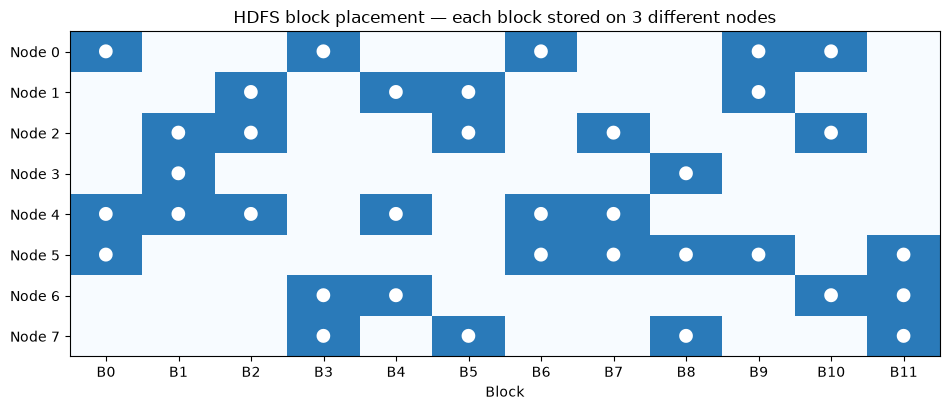

Every column has exactly 3 marks — lose any one row (node) and every column still has 2.


In [18]:
# Draw the placement of the first few blocks across the cluster.
rng_blocks = np.random.default_rng(5)
n_shown = 12
placement = np.zeros((n_nodes, n_shown))
for block in range(n_shown):
    chosen = rng_blocks.choice(n_nodes, replication, replace=False)
    placement[chosen, block] = 1

fig, ax = plt.subplots(figsize=(9.6, 4.2))
ax.imshow(placement, cmap="Blues", aspect="auto", vmin=0, vmax=1.4)
ax.set_xticks(range(n_shown), [f"B{i}" for i in range(n_shown)])
ax.set_yticks(range(n_nodes), [f"Node {i}" for i in range(n_nodes)])
ax.set_xlabel("Block")
ax.set_title(f"HDFS block placement — each block stored on {replication} different nodes")
for node in range(n_nodes):
    for block in range(n_shown):
        if placement[node, block]:
            ax.text(block, node, "●", ha="center", va="center", color="white", fontsize=13)
ax.grid(False)
plt.show()

print("Every column has exactly 3 marks — lose any one row (node) and every column still has 2.")

**How to read it:** read the chart by **column**. Each block appears on three different nodes, so deleting any
single row still leaves every column covered. That is fault tolerance bought with disk space: you pay 3× the
storage to make single-machine failure a non-event.

It also enables something subtler. Because every block exists in three places, the scheduler can run a
computation **on a machine that already holds the data** — "move the computation to the data" — instead of
shipping terabytes across the network. In a cluster, the network is usually the bottleneck, so this is a
larger win than it sounds.

#### MapReduce — the programming model

**Map**: each node processes its own chunk independently. **Reduce**: combine every node's partial answers
into one final result. The lecture's example counts words in customer feedback.

In [19]:
# A "big dataset" — four customer-feedback sentences.
feedback = [
    "great service fast delivery",
    "fast delivery great prices",
    "great prices poor service",
    "poor packaging fast delivery",
]

# MAP step: each node counts words in its own chunk, independently.
def map_step(chunk):
    counts = {}
    for sentence in chunk:
        for word in sentence.split():
            counts[word] = counts.get(word, 0) + 1
    return counts

n_nodes = 2
chunks = [feedback[i::n_nodes] for i in range(n_nodes)]
partial_counts = [map_step(chunk) for chunk in chunks]

print("MAP — partial counts from each node:")
for i, (chunk, counts) in enumerate(zip(chunks, partial_counts)):
    print(f"  Node {i} saw {chunk}")
    print(f"         -> {counts}")

# REDUCE step: combine every node's partial results into one final answer.
final_counts = {}
for counts in partial_counts:
    for word, n in counts.items():
        final_counts[word] = final_counts.get(word, 0) + n

print("\nREDUCE — final word counts:")
for word, count in sorted(final_counts.items(), key=lambda item: (-item[1], item[0])):
    print(f"  {word:12s} {count}")

MAP — partial counts from each node:
  Node 0 saw ['great service fast delivery', 'great prices poor service']
         -> {'great': 2, 'service': 2, 'fast': 1, 'delivery': 1, 'prices': 1, 'poor': 1}
  Node 1 saw ['fast delivery great prices', 'poor packaging fast delivery']
         -> {'fast': 2, 'delivery': 2, 'great': 1, 'prices': 1, 'poor': 1, 'packaging': 1}

REDUCE — final word counts:
  delivery     3
  fast         3
  great        3
  poor         2
  prices       2
  service      2
  packaging    1


**How to read it:** each node only ever saw *half* the sentences, yet the reduce step combines their partial
answers into the exact same result you would get counting everything on one machine. That is what makes
distributed processing reliable.

The property that makes this work is that **counting is associative and commutative** — you can add partial
sums in any order and get the same total. Not every computation has that property, and the ones that do not
(a median, for example) are genuinely harder to distribute.

> ✏️ **Try it:** change `n_nodes` to `4` and re-run. The final counts must stay exactly the same — only the
> split changes. Then try writing a map/reduce that computes the *average* word length. Why does averaging
> need each node to return **two** numbers rather than one?

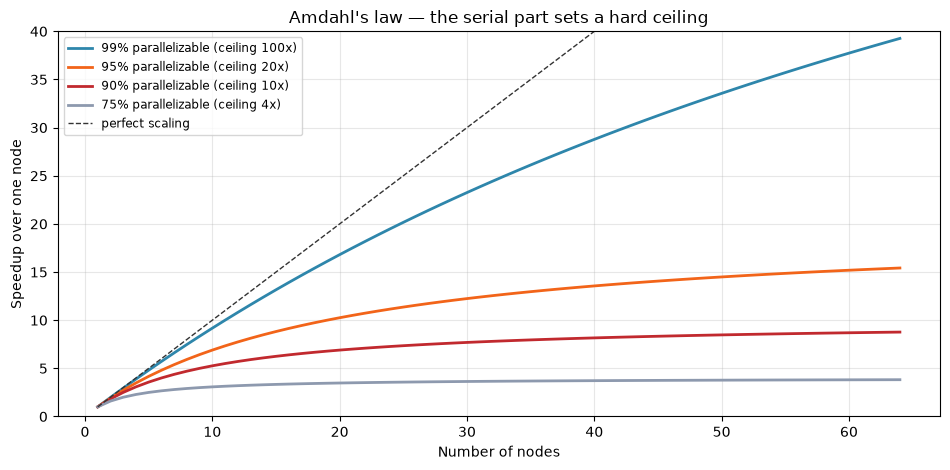

99% parallel: 64 nodes give 39.3x, but the ceiling at infinite nodes is 100x
90% parallel: 64 nodes give 8.8x, but the ceiling at infinite nodes is 10x
75% parallel: 64 nodes give 3.8x, but the ceiling at infinite nodes is 4x


In [20]:
# Does adding nodes always help? Amdahl's law says no.
def speedup(n_workers, parallel_fraction):
    serial = 1 - parallel_fraction
    return 1 / (serial + parallel_fraction / n_workers)

workers = np.arange(1, 65)

fig, ax = plt.subplots(figsize=(9.6, 4.8))
for fraction, color in [(0.99, "#2E86AB"), (0.95, "#F26419"), (0.90, "#C1292E"), (0.75, "#8D99AE")]:
    ax.plot(workers, [speedup(w, fraction) for w in workers], linewidth=2,
            color=color, label=f"{fraction:.0%} parallelizable (ceiling {1/(1-fraction):.0f}x)")
ax.plot(workers, workers, "--", color="#333", linewidth=1, label="perfect scaling")
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Speedup over one node")
ax.set_title("Amdahl's law — the serial part sets a hard ceiling")
ax.set_ylim(0, 40)
ax.legend(fontsize=8.5)
plt.show()

for fraction in (0.99, 0.90, 0.75):
    print(f"{fraction:.0%} parallel: 64 nodes give {speedup(64, fraction):.1f}x, "
          f"but the ceiling at infinite nodes is {1/(1-fraction):.0f}x")

**How to read it:** every curve flattens, and none reaches the dashed line. If 10% of a job cannot be
parallelized — reading the input, writing the output, the final reduce — then **no number of machines can
make it more than 10× faster**, because that 10% still has to happen sequentially.

$$\text{speedup}(n) = \frac{1}{(1 - p) + p/n}$$

where *p* is the parallelizable fraction. The practical consequence: doubling the cluster rarely halves the
runtime, and past some point the extra nodes are pure cost. Measure before you scale.

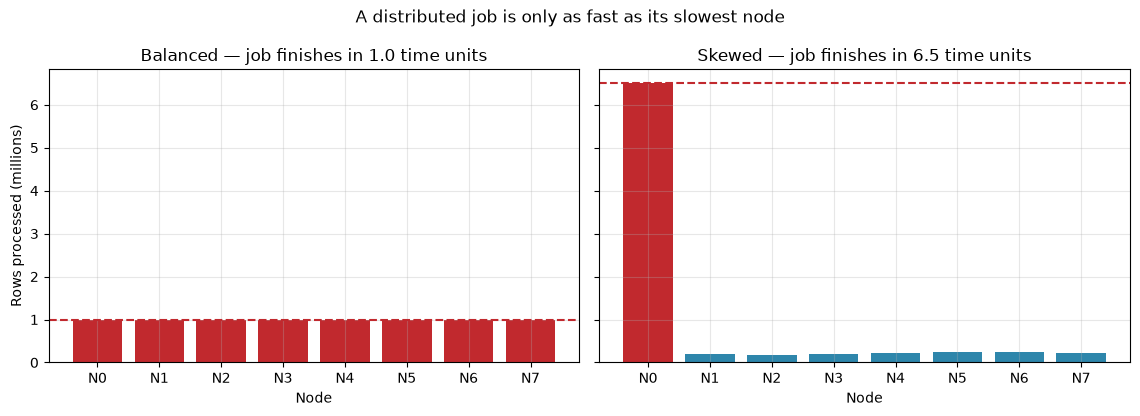

Total work is identical: 8,000,000 vs 8,000,000 rows.
Balanced job finishes in 1,000,000 units of work.
Skewed job finishes in   6,500,000 units — 6.5x slower, with 7 nodes sitting idle.


In [21]:
# The other thing that ruins distributed jobs: skew.
n_nodes = 8

balanced = np.full(n_nodes, 1_000_000)
skewed = np.array([6_500_000, 200_000, 180_000, 190_000, 210_000, 250_000, 240_000, 230_000])

fig, (ax_bal, ax_skew) = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, load, title in [(ax_bal, balanced, "Balanced"), (ax_skew, skewed, "Skewed")]:
    colors = ["#C1292E" if value == load.max() else "#2E86AB" for value in load]
    ax.bar(range(n_nodes), load / 1e6, color=colors)
    ax.axhline(load.max() / 1e6, color="#C1292E", linestyle="--", linewidth=1.5)
    ax.set_xticks(range(n_nodes), [f"N{i}" for i in range(n_nodes)])
    ax.set_xlabel("Node")
    ax.set_title(f"{title} — job finishes in {load.max()/1e6:.1f} time units")
ax_bal.set_ylabel("Rows processed (millions)")
fig.suptitle("A distributed job is only as fast as its slowest node")
plt.show()

print(f"Total work is identical: {balanced.sum():,} vs {skewed.sum():,} rows.")
print(f"Balanced job finishes in {balanced.max():,} units of work.")
print(f"Skewed job finishes in   {skewed.max():,} units — "
      f"{skewed.max()/balanced.max():.1f}x slower, with 7 nodes sitting idle.")

**How to read it:** the two clusters do exactly the same total amount of work, and one takes over six times
longer. The job cannot finish until the last node finishes, so **one overloaded node sets the wall-clock
time** while the rest sit idle.

Skew usually comes from the data, not the code. Partition customer records by country and the largest country
gets an enormous partition; group web logs by URL and the home page dwarfs everything. When a distributed job
is mysteriously slow, check the per-partition row counts before you blame the algorithm.

---
## 4. Data mining, analytics, and visualization tools

Three categories, each one step closer to something a human can read at a glance.

| Category | Tools | What they are for |
|---|---|---|
| **Data mining** | RapidMiner, Elasticsearch | Extracting specific patterns from large datasets |
| **Data analytics** | Apache Spark, R (and pandas!) | Ordering and organizing raw data into insights |
| **Data visualization** | Tableau, Plotly/Dash (and matplotlib!) | Representing patterns visually |

A few notes on the named tools, since the slide gives only a category:

- **Elasticsearch** is a search and analytics engine built on an *inverted index* — a map from each word to
  the documents containing it. That is what makes full-text search over billions of documents fast, and it is
  the same structure Chapter 12 builds for text mining.
- **Apache Spark** is the modern successor to MapReduce. Its key advance is keeping intermediate results in
  memory across steps, rather than writing to disk between every map and reduce, which makes iterative
  algorithms (most of machine learning) dramatically faster.
- **R** is a language built by statisticians for statistics. Python won the general-purpose fight; R remains
  strong wherever the statistics are the hard part.
- **Tableau** is a commercial drag-and-drop visualization tool aimed at analysts who do not code. Its
  strength is speed to a first chart; its weakness is that the analysis is not a script and therefore not
  reproducible or version-controlled.

In [22]:
# The inverted index behind a search engine, in eight lines.
documents = {
    1: "great service fast delivery",
    2: "fast delivery great prices",
    3: "great prices poor service",
    4: "poor packaging fast delivery",
}

inverted_index = {}
for doc_id, text in documents.items():
    for word in set(text.split()):
        inverted_index.setdefault(word, set()).add(doc_id)

print("Inverted index — word -> documents containing it:")
for word in sorted(inverted_index):
    print(f"  {word:12s} {sorted(inverted_index[word])}")

# A search is now a set intersection, not a scan of every document.
query = ["fast", "delivery"]
matches = set.intersection(*(inverted_index.get(word, set()) for word in query))
print(f"\nSearch for {query}: documents {sorted(matches)}")
print("Note that NO document text was read to answer that — only the index.")

Inverted index — word -> documents containing it:
  delivery     [1, 2, 4]
  fast         [1, 2, 4]
  great        [1, 2, 3]
  packaging    [4]
  poor         [3, 4]
  prices       [2, 3]
  service      [1, 3]

Search for ['fast', 'delivery']: documents [1, 2, 4]
Note that NO document text was read to answer that — only the index.


**How to read it:** answering the query never touched a single document. Scanning every document would cost
time proportional to the total text; the index answers in time proportional to the number of *matches*. On
four documents that is irrelevant; on four billion it is the difference between a search engine and a
non-functioning website.

This is a general and important pattern: **build an index once, answer many queries cheaply.** It is the same
bargain a database index makes, and the same one Chapter 12's document-term matrix makes.

---
## 5. Emerging technologies

| Tool | What it is |
|---|---|
| **TensorFlow** | Infrastructure for machine learning — spots complex patterns in data to make predictions |
| **Docker** | Packages an app with everything it needs into a *container*, so it runs identically anywhere |
| **Apache Beam** | A portable API layer for parallel data-processing pipelines running on multiple engines |
| **Apache Airflow** | Workflow automation and scheduling, built around DAGs (Directed Acyclic Graphs) of tasks |

**Docker vs. a virtual machine.** A VM includes an entire guest operating system; a container shares the
host's OS kernel and packages only the application and its libraries. That is what makes containers start in
seconds and measure in megabytes, where VMs start in minutes and measure in gigabytes.

The problem Docker actually solves has a name: *"it works on my machine."* If the container image specifies
the exact Python version, the exact library versions, and the exact system packages, then it works on every
machine — including the one running it in production two years from now.

In [23]:
comparison = pd.DataFrame([
    ("Includes a full guest OS",    "Yes",              "No — shares the host kernel"),
    ("Typical image size",          "1–20 GB",          "10–500 MB"),
    ("Typical start time",          "Tens of seconds to minutes", "Under a second"),
    ("Isolation strength",          "Very strong",      "Strong, but weaker than a VM"),
    ("How many on one laptop",      "A few",            "Dozens"),
    ("Good for",                    "Different OS, strict isolation", "Packaging and shipping an app"),
], columns=["", "Virtual machine", "Container (Docker)"]).set_index("")

comparison

,Virtual machine,Container (Docker)
,,
Includes a full guest OS,Yes,No — shares the host kernel
Typical image size,1–20 GB,10–500 MB
Typical start time,Tens of seconds to minutes,Under a second
Isolation strength,Very strong,"Strong, but weaker than a VM"
How many on one laptop,A few,Dozens
Good for,"Different OS, strict isolation",Packaging and shipping an app


### 5.1 A pipeline as a graph of dependencies

A **DAG** (Directed Acyclic Graph) has no cycles, so every task has a clear order to run in. Airflow builds
pipelines this way and checks the acyclic property before running anything.

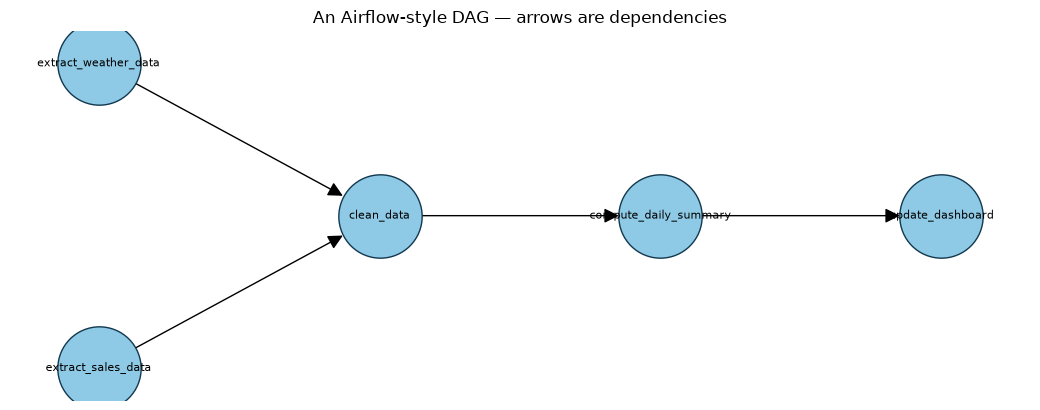

Is this a DAG (no cycles)? True

A valid execution order (topological sort):
  1. extract_sales_data
  2. extract_weather_data
  3. clean_data
  4. compute_daily_summary
  5. update_dashboard


In [24]:
dag = nx.DiGraph()
dag.add_edges_from([
    ("extract_sales_data", "clean_data"),
    ("extract_weather_data", "clean_data"),
    ("clean_data", "compute_daily_summary"),
    ("compute_daily_summary", "update_dashboard"),
])

# Lay the graph out in dependency order rather than randomly, so the flow reads left to right.
levels = {}
for node in nx.topological_sort(dag):
    predecessors = list(dag.predecessors(node))
    levels[node] = 0 if not predecessors else max(levels[p] for p in predecessors) + 1

positions = {}
for level in set(levels.values()):
    nodes_here = [n for n, lvl in levels.items() if lvl == level]
    for i, node in enumerate(sorted(nodes_here)):
        positions[node] = (level, i - (len(nodes_here) - 1) / 2)

fig, ax = plt.subplots(figsize=(10.5, 4.2))
nx.draw(dag, positions, ax=ax, with_labels=True, node_color="#8ECAE6", node_size=3600,
        font_size=8, arrowsize=22, edgecolors="#12384f")
ax.set_title("An Airflow-style DAG — arrows are dependencies")
ax.grid(False)
plt.show()

print("Is this a DAG (no cycles)?", nx.is_directed_acyclic_graph(dag))
print("\nA valid execution order (topological sort):")
for step, task in enumerate(nx.topological_sort(dag), start=1):
    print(f"  {step}. {task}")

**How to read it:** the arrows show dependencies. `clean_data` cannot run until **both** extraction tasks
finish; `update_dashboard` is the very last step. The topological sort is the scheduler's job — turning a set
of dependencies into a legal running order.

Notice that the two extraction tasks have no dependency between them, so they can run **in parallel**. That
is the second thing a DAG buys you: the graph itself says what may run concurrently, without anyone writing
threading code.

In [25]:
# Why "acyclic" matters — a pipeline with a cycle can never start.
broken = nx.DiGraph()
broken.add_edges_from([
    ("clean_data", "compute_summary"),
    ("compute_summary", "validate"),
    ("validate", "clean_data"),        # <- points back, creating a cycle
])

print("Is the broken pipeline a DAG?", nx.is_directed_acyclic_graph(broken))
try:
    list(nx.topological_sort(broken))
except nx.NetworkXUnfeasible:
    print("There is NO valid execution order — every task waits on another.")
    print("Cycle found:", nx.find_cycle(broken))

print("\nAirflow refuses to run this at all, rather than starting and hanging forever.")

Is the broken pipeline a DAG? False
There is NO valid execution order — every task waits on another.
Cycle found: [('clean_data', 'compute_summary'), ('compute_summary', 'validate'), ('validate', 'clean_data')]

Airflow refuses to run this at all, rather than starting and hanging forever.


**How to read it:** with a cycle, every task is waiting for another task in the loop, so none can start. There
is no execution order to find, and the scheduler says so **before** running anything rather than deadlocking
at three in the morning.

This is a small but genuine example of a good design principle: make the invalid state *unrepresentable*, and
check it early. The alternative — discovering the problem at runtime — is how pipelines eat weekends.

> ✏️ **Try it:** add a `send_email` task that depends on `update_dashboard`, and a `log_run` task that depends
> on nothing. Re-run the topological sort. Where does `log_run` appear, and does its position matter?

---
## 6. Choosing the right tool

There is no single "best" big data technology. The right choice depends on the shape of your data and what
you need to do with it.

| Data shape | Needs flexibility? | Recommendation |
|---|---|---|
| Tabular | No | **RDBMS** — structured, fixed schema, relationships via keys |
| Tabular | Yes | **NoSQL document store** — flexible schema, still record-like |
| Network | Yes | **NoSQL graph store** — entities and relationships |
| Other | Yes | **NoSQL key-value store** — simple lookups, maximum flexibility |

In [26]:
def recommend_storage(data_shape, needs_flexibility):
    # The lecture's decision helper, following the categories from Section 3.
    if data_shape == "tabular" and not needs_flexibility:
        return "RDBMS (structured, fixed schema, relationships via keys)"
    elif data_shape == "tabular" and needs_flexibility:
        return "NoSQL document store (flexible schema, still record-like)"
    elif data_shape == "network":
        return "NoSQL graph store (entities + relationships)"
    return "NoSQL key-value store (simple lookups, maximum flexibility)"

for shape, flexible in [("tabular", False), ("tabular", True), ("network", True), ("other", True)]:
    print(f"{shape:8s} flexible={str(flexible):5s} -> {recommend_storage(shape, flexible)}")

tabular  flexible=False -> RDBMS (structured, fixed schema, relationships via keys)
tabular  flexible=True  -> NoSQL document store (flexible schema, still record-like)
network  flexible=True  -> NoSQL graph store (entities + relationships)
other    flexible=True  -> NoSQL key-value store (simple lookups, maximum flexibility)


In [27]:
# A fuller helper, adding the workload and scale questions from Sections 1 and 3.
def recommend(data_shape, needs_flexibility, workload, scale_tb, query_pattern="mixed"):
    reasons, choice = [], None

    if data_shape == "network":
        choice, _ = "NoSQL graph store", reasons.append("the data is about connections, not records")
    elif query_pattern == "key lookup":
        choice, _ = "NoSQL key-value store", reasons.append("every access is by a single known key")
    elif workload == "analytical" and scale_tb >= 10:
        choice, _ = "Column store / data warehouse on cloud storage", reasons.append(
            "analytical scans over a large volume favor column layout")
    elif workload == "analytical":
        choice, _ = "Data warehouse (columnar) or plain files + pandas", reasons.append(
            "analytical, but small enough for a single machine")
    elif needs_flexibility:
        choice, _ = "NoSQL document store", reasons.append("records vary in which fields they carry")
    else:
        choice, _ = "RDBMS", reasons.append("fixed schema and transactional correctness matter")

    if scale_tb >= 100:
        reasons.append(f"at {scale_tb} TB, plan for distributed storage (HDFS or cloud object storage)")
    if workload == "operational":
        reasons.append("operational workload: prioritize latency and ACID guarantees")
    return choice, reasons

cases = [
    ("A bank's core ledger",              dict(data_shape="tabular", needs_flexibility=False,
                                               workload="operational", scale_tb=5)),
    ("Five years of clickstream logs",    dict(data_shape="tabular", needs_flexibility=True,
                                               workload="analytical", scale_tb=400)),
    ("A fraud ring investigation",        dict(data_shape="network", needs_flexibility=True,
                                               workload="analytical", scale_tb=2)),
    ("A session cache for a website",     dict(data_shape="other", needs_flexibility=True,
                                               workload="operational", scale_tb=0.1,
                                               query_pattern="key lookup")),
    ("Product catalog with varying specs", dict(data_shape="tabular", needs_flexibility=True,
                                                workload="operational", scale_tb=0.5)),
]

for name, kwargs in cases:
    choice, reasons = recommend(**kwargs)
    print(f"{name}\n  -> {choice}")
    for reason in reasons:
        print(f"     because {reason}")
    print()

A bank's core ledger
  -> RDBMS
     because fixed schema and transactional correctness matter
     because operational workload: prioritize latency and ACID guarantees

Five years of clickstream logs
  -> Column store / data warehouse on cloud storage
     because analytical scans over a large volume favor column layout
     because at 400 TB, plan for distributed storage (HDFS or cloud object storage)

A fraud ring investigation
  -> NoSQL graph store
     because the data is about connections, not records

A session cache for a website
  -> NoSQL key-value store
     because every access is by a single known key
     because operational workload: prioritize latency and ACID guarantees

Product catalog with varying specs
  -> NoSQL document store
     because records vary in which fields they carry
     because operational workload: prioritize latency and ACID guarantees



**How to read it:** the helper's *reasons* matter more than its answers. A recommendation you cannot justify
is not a recommendation, and in a real project you would be asked "why not the thing we already have?" — a
question this function's reason list is designed to answer.

Note also what the helper deliberately ignores: what the team already knows, what is already running, and what
it costs to operate. A technically superior tool that nobody on the team can run is the wrong tool.
**"Boring technology that the team understands" beats "the best fit on paper" more often than any textbook
admits.**

> ✏️ **Try it:** add a `team_experience` argument (`"none"`, `"some"`, `"strong"`) and make the function
> downgrade an exotic recommendation to the nearest familiar option when experience is `"none"`. What did you
> have to decide about how much a bad fit is worth versus a steep learning curve?

---
## 7. Glossary

| Term | Meaning |
|---|---|
| **Operational (OLTP)** | Real-time workloads capturing and storing one record at a time |
| **Analytical (OLAP)** | Retrospective analysis touching most or all of the data |
| **Row storage / column storage** | Fields of one record adjacent / values of one field adjacent |
| **ACID** | Atomicity, Consistency, Isolation, Durability — the transactional guarantee |
| **BASE** | Basically Available, Soft state, Eventually consistent |
| **CAP theorem** | During a network partition, choose consistency or availability |
| **RDBMS** | Relational database: fixed tables, SQL, related by keys |
| **Primary key / foreign key** | Uniquely identifies a row / points at another table's primary key |
| **Normalization** | Storing each fact exactly once to prevent update anomalies |
| **Join (inner/left/outer)** | Combining tables on a shared key; the type decides what is kept |
| **NoSQL** | Non-relational stores: key-value, document, column-based, graph |
| **Cloud storage** | Data on remote hardware, reachable over the internet |
| **Storage tier** | Hot / cool / archive — cheaper to keep, dearer to read |
| **Egress cost** | The charge for data leaving a cloud provider |
| **HDFS** | Hadoop Distributed File System — blocks scattered and replicated across a cluster |
| **Block / replication factor** | The unit a file is split into / how many copies of each are kept |
| **YARN** | Hadoop's resource manager for parallel processing |
| **MapReduce** | Process chunks independently (map), combine partial answers (reduce) |
| **Data locality** | Running the computation on the machine that already holds the data |
| **Amdahl's law** | The serial fraction of a job caps its possible speedup |
| **Skew** | Unequal partition sizes; the slowest node sets the runtime |
| **Apache Spark** | In-memory successor to MapReduce |
| **Inverted index** | Word → documents containing it; the basis of search |
| **Container / Docker** | An app plus its dependencies, sharing the host OS kernel |
| **DAG** | Directed Acyclic Graph — tasks and dependencies, with no cycles |
| **Topological sort** | A valid execution order derived from a DAG |

---
## 8. Check your understanding

**Q1.** A ride-hailing app must record each ride the instant it ends, and separately produce a monthly report
on average trip length by district. How many systems is that, and why?

<details><summary>Answer</summary>

Two workloads, usually two systems. Recording a ride is operational — one record, low latency, ACID matters.
The monthly report is analytical — a scan over millions of rows with no deadline. Running the report against
the operational database would slow down the thing customers are waiting on, which is why analytical copies
exist.
</details>

**Q2.** Why do analytical databases store data by column?

<details><summary>Answer</summary>

Analytical queries read a few columns across many rows. Column layout puts those values next to each other, so
the query never touches the columns it does not need. Section 1.1 measured a large speedup on exactly this
pattern.
</details>

**Q3.** Your shopping site's product catalog goes offline during a network partition rather than showing
slightly stale prices. Was that the right CAP choice?

<details><summary>Answer</summary>

Almost certainly not. A catalog is a classic AP case — a price a few seconds out of date costs little, being
unreachable costs sales. Reserve CP for things that must not diverge, like inventory counts or seat
reservations.
</details>

**Q4.** You join two tables and the row count goes *up*. What happened?

<details><summary>Answer</summary>

The join key is not unique on one side, so each left row matched several right rows and was duplicated. Check
with `.duplicated()` on the key. A row count that goes *down* is the opposite problem — unmatched keys dropped
by an inner join.
</details>

**Q5.** Why not just store the department name in the people table?

<details><summary>Answer</summary>

Update anomalies. The name is then stored many times, and a rename must find every copy. Normalization stores
each fact once. Analytical systems often denormalize anyway, because they are read-only and joins cost time —
the right answer depends on the workload.
</details>

**Q6.** You archive 500 TB to the cheapest cloud tier, and analysts then read most of it every month. What
goes wrong, and what would you check before blaming the tier?

<details><summary>Answer</summary>

Retrieval charges. Archive is far cheaper to store and dramatically more expensive per gigabyte read, so once
the monthly read fraction rises past the crossover point in Section 3.3, the archive tier becomes the most
expensive option. Check the actual read fraction first — at low read volumes archive genuinely is cheapest,
and the second thing to check is retrieval *latency*, which can rule out archive regardless of price.
</details>

**Q7.** HDFS replicates every block three times. Isn't tripling storage wasteful?

<details><summary>Answer</summary>

It buys two things. Fault tolerance: any single node can die with no data loss. And data locality: with three
copies, the scheduler can almost always run a computation on a machine that already holds the block, avoiding
a network transfer. Disk is cheap; network bandwidth and downtime are not.
</details>

**Q8.** A job is 90% parallelizable. Your manager wants it 20× faster and offers 64 machines. What do you say?

<details><summary>Answer</summary>

It is not possible. By Amdahl's law the ceiling at 90% parallel is 10× no matter how many machines you add,
and 64 machines gets about 8.8×. The way to 20× is to shrink the serial 10%, not to buy hardware.
</details>

**Q9.** A distributed job with 8 nodes takes as long as it did with 2. What would you check first?

<details><summary>Answer</summary>

Skew. Look at rows processed per partition. If one node has most of the data, the job finishes when that node
does and the others idle. Repartitioning on a better key usually fixes it — and no amount of extra nodes will.
</details>

**Q10.** What does a DAG give you beyond a list of steps?

<details><summary>Answer</summary>

Two things. It states which tasks may run **in parallel** (any tasks with no dependency path between them),
and it makes an impossible pipeline detectable **before** it runs, because a cycle has no topological order.
</details>

---
## 9. Summary — key takeaways

1. **Operational vs. analytical** is the first fork in the road: real-time capture and storage, or
   retrospective analysis over everything. Almost every later choice follows from it.
2. **The workload dictates the physical layout.** Row storage for whole records, column storage for whole
   columns — and the gap between them is large.
3. **ACID and BASE are different promises**, and CAP explains why: during a network partition you choose
   consistency or availability, not both.
4. **Four tool categories** — storage, mining, analytics, visualization. You already use two of them.
5. **RDBMS relates through keys**, and normalization stores each fact exactly once. Joins are where data
   silently disappears; check row counts every time.
6. **NoSQL has four shapes** — key-value, document, column-based, graph. Pick the one that matches the shape
   of your data, especially for graphs, where the alternative degrades badly.
7. **Cloud storage removes the hardware ceiling** but introduces tiers and egress costs; match the tier to the
   access pattern.
8. **Distributed computing scales, with limits.** HDFS splits and replicates; MapReduce splits and combines.
   Amdahl's law caps the speedup, and skew wastes it.
9. **Containers and DAGs make pipelines reproducible and schedulable**, and both work by making invalid states
   impossible rather than by catching them later.
10. **There is no single best tool.** The right choice depends on the shape of the data, the workload, the
    scale — and on what your team can actually operate.

### Where this goes next

- **Chapter 6 — Data Preparation**: what happens to the data after it comes out of these systems.
- **Chapter 7 — Data Visualization**: the fourth category, in depth.
- **Chapter 9 — Machine Learning**: what TensorFlow is infrastructure *for*.
- **Chapter 12 — Text Mining**: builds the inverted index from Section 4 for real.

### Further reading

Beyond the lecture:

1. Brewer, E. (2000). *Towards robust distributed systems* — the original CAP conjecture.
2. Dean, J. and Ghemawat, S. (2004). *MapReduce: Simplified data processing on large clusters* — the paper
   behind Section 3.4.
3. Shvachko, K. et al. (2010). *The Hadoop Distributed File System.*
4. Zaharia, M. et al. (2012). *Resilient Distributed Datasets* — the paper behind Apache Spark.
5. Kleppmann, M. (2017). *Designing Data-Intensive Applications* — the standard modern reference for
   everything in Sections 1 and 3.
6. Amdahl, G. (1967). *Validity of the single processor approach to achieving large scale computing
   capabilities.*

## 10. Homework 📝

### 👤 Student information

**Name:**  *(double-click to edit this cell and fill in your name)*

**Student ID:**

**Date:**

### The homework dataset — 🏥 ClinicChain patient records

Run the cell below to generate two small, related tables for a fictional clinic chain: patients and their
appointments. **Do not modify it** — everyone's numbers must match.

In [28]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)

clinics = pd.DataFrame({
    "clinic_id": [1, 2, 3],
    "clinic_name": ["ClinicChain Riverside", "ClinicChain Central", "ClinicChain Hillside"],
})

n_patients = 12
patients = pd.DataFrame({
    "patient_id": range(1, n_patients + 1),
    "patient_name": [f"Patient_{i}" for i in range(1, n_patients + 1)],
    "clinic_id": hw_rng.integers(1, 4, n_patients),
})

n_appts = 20
appointments = pd.DataFrame({
    "appointment_id": range(1, n_appts + 1),
    "patient_id": hw_rng.integers(1, n_patients + 1, n_appts),
    "wait_minutes": hw_rng.integers(2, 60, n_appts),
})

print(clinics)
print()
print(patients.head())
print()
print(appointments.head())

   clinic_id            clinic_name
0          1  ClinicChain Riverside
1          2    ClinicChain Central
2          3   ClinicChain Hillside

   patient_id patient_name  clinic_id
0           1    Patient_1          3
1           2    Patient_2          2
2           3    Patient_3          2
3           4    Patient_4          3
4           5    Patient_5          2

   appointment_id  patient_id  wait_minutes
0               1           9            32
1               2          10            14
2               3           5            18
3               4           8            30
4               5           6             3


---

### Exercise 1 — Operational or analytical?

Classify each of these ClinicChain systems as **operational** or **analytical**, with one sentence of
justification each: (a) the check-in kiosk that saves a new appointment the moment a patient arrives; (b) a
year-end report analyzing average wait times across all three clinics to plan next year's staffing.

In [29]:
# YOUR CODE HERE (Exercise 1)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---

### Exercise 2 — RDBMS-style joins

Using `.merge()` (like Section 3.1), join `patients` with `clinics` to show each patient's clinic name. Then
join the result with `appointments` to compute the **average wait time per clinic**.

In [30]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---

### Exercise 3 — Match the NoSQL model

For each of the following, name which NoSQL model (key-value / document / column-based / graph-based) fits
best, and why:

1. A record of which patients have referred which other patients to the clinic.
2. A fast lookup table mapping each patient's ID card barcode directly to their patient ID.
3. Each patient's intake form, where some patients answered optional fields and others left them blank.

In [31]:
# YOUR CODE HERE (Exercise 3)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 3:**

---

### Exercise 4 — Cloud storage market share

Using the `cloud_market_share` Series from Section 3.3, compute the combined market share of the **top 3**
providers. Then create your own bar chart (not pie chart) of the same data, sorted from largest to smallest.

In [32]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---

### Exercise 5 — Distributed word counting

Using the MapReduce pattern from Section 3.4, count how many times each `clinic_name` appears across all
patients (i.e. how many patients each clinic has), by splitting `patients` into **3 chunks**, running a
"map" step on each chunk, then "reducing" the partial results into one final count. Compare your final answer
to `patients["clinic_id"].value_counts()` to check it matches.

In [33]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---

### Exercise 6 — Pick the right tool

For each task, name which category from Section 2 (storage, mining, analytics, visualization) it belongs to,
and suggest one named tool: (a) building an interactive dashboard for clinic managers; (b) finding frequent
symptom combinations across thousands of patient records; (c) storing 10 years of appointment history.

In [34]:
# YOUR CODE HERE (Exercise 6)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 6:**

---

### Bonus — Design a pipeline DAG

ClinicChain wants to automate a nightly pipeline: (1) extract new appointments, (2) extract new patient
sign-ups, (3) merge them into one daily report, (4) email the report to clinic managers. Using
`networkx.DiGraph` like Section 5, build and draw this DAG, and name which emerging technology (TensorFlow,
Docker, Beam, or Airflow) is the best fit for *scheduling and running* this pipeline, and why.

In [35]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---

### ✅ Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file